In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import sklearn

In [ ]:
df=pd.read_csv("NTM_Vib.csv")
df.head()

,Size,Date,RPM,NTM Stand,Line,Entry Vib,Exit Vib
0,5.5mm,05/10/23,661.0,19,Line A,0.83,1.08
1,5.5mm,05/10/23,743.0,19,Line B,1.70,2.37
2,5.5mm,05/10/23,661.0,20,Line A,0.62,0.79
3,5.5mm,05/10/23,743.0,20,Line B,0.98,1.06
4,5.5mm,05/10/23,661.0,21,Line A,0.83,1.12


In [ ]:
df = df[df['Entry Vib'] < 50].copy()

# Handle missing RPM - fill with median RPM per stand (better than global median)
df['RPM'] = df.groupby('NTM Stand')['RPM'].transform(lambda x: x.fillna(x.median()))

# Drop any remaining nulls
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.head()

(1534, 7)


,Size,Date,RPM,NTM Stand,Line,Entry Vib,Exit Vib
0,5.5mm,05/10/23,661.0,19,Line A,0.83,1.08
1,5.5mm,05/10/23,743.0,19,Line B,1.70,2.37
2,5.5mm,05/10/23,661.0,20,Line A,0.62,0.79
3,5.5mm,05/10/23,743.0,20,Line B,0.98,1.06
4,5.5mm,05/10/23,661.0,21,Line A,0.83,1.12


AttributeError: module 'matplotlib' has no attribute 'title'

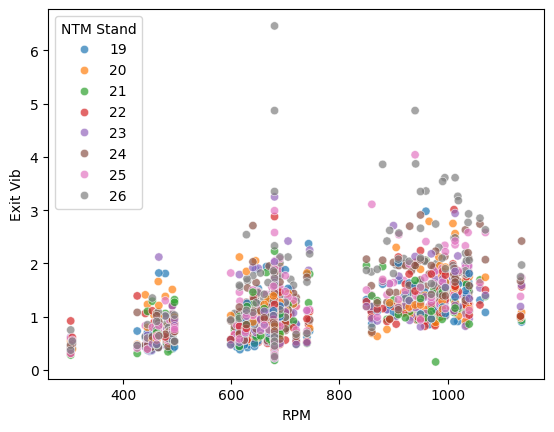

In [ ]:

sns.scatterplot(data=df, x='RPM', y='Exit Vib', hue='NTM Stand', palette='tab10', alpha=0.7)
plt.title('RPM vs Exit Vibration, colored by Stand')
plt.show()

In [ ]:
# Encode categorical columns
df_model = df.copy()
df_model['Line_enc'] = df_model['Line'].map({'Line A': 0, 'Line B': 1})

# Vibration normalized by RPM - this is the feature that captures "unusual for this speed"
df_model['Exit_Vib_per_RPM'] = df_model['Exit Vib'] / df_model['RPM']
df_model['Entry_Vib_per_RPM'] = df_model['Entry Vib'] / df_model['RPM']

features = ['RPM', 'Entry Vib', 'Exit Vib', 'Entry_Vib_per_RPM', 'Exit_Vib_per_RPM', 'NTM Stand', 'Line_enc']
X = df_model[features]
X.head()

,RPM,Entry Vib,Exit Vib,Entry_Vib_per_RPM,Exit_Vib_per_RPM,NTM Stand,Line_enc
0,661.0,0.83,1.08,0.001256,0.001634,19,0
1,743.0,1.70,2.37,0.002288,0.003190,19,1
2,661.0,0.62,0.79,0.000938,0.001195,20,0
3,743.0,0.98,1.06,0.001319,0.001427,20,1
4,661.0,0.83,1.12,0.001256,0.001694,21,0


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # assume ~5% of data is anomalous - adjustable
    random_state=42
)

df_model['anomaly'] = iso.fit_predict(X)  # -1 = anomaly, 1 = normal
df_model['anomaly_score'] = iso.decision_function(X)  # lower = more anomalous

print(df_model['anomaly'].value_counts())

anomaly
 1    1457
-1      77
Name: count, dtype: int64


AttributeError: module 'matplotlib' has no attribute 'title'

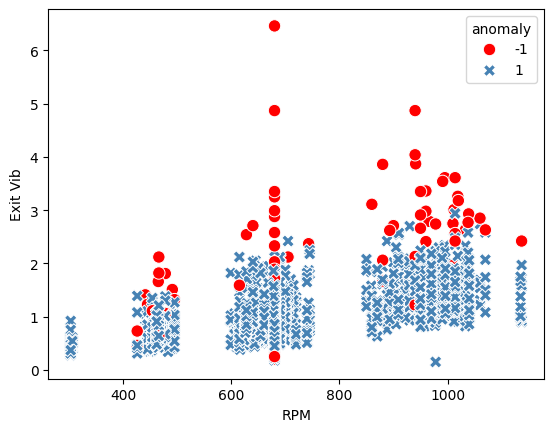

In [ ]:


sns.scatterplot(
    data=df_model,
    x='RPM',
    y='Exit Vib',
    hue='anomaly',
    palette={1: 'steelblue', -1: 'red'},
    style='anomaly',
    s=80
)
plt.title('Isolation Forest Flagged Anomalies')
plt.show()

In [ ]:
anomalous_sorted = df_model[df_model['anomaly'] == -1].sort_values('anomaly_score')
anomalous_sorted[['Size', 'Date', 'RPM', 'NTM Stand', 'Line', 'Entry Vib', 'Exit Vib', 'anomaly_score']]

,Size,Date,RPM,NTM Stand,Line,Entry Vib,Exit Vib,anomaly_score
478,7mm,18/09/24,680.0,26,Line B,5.29,4.87,-0.197243
893,10mm,08/11/25,680.0,26,Line A,4.75,6.46,-0.196344
846,10mm,10/03/25,940.0,26,Line B,4.49,4.87,-0.179618
558,7mm,22/04/25,880.0,26,Line B,3.65,3.86,-0.155642
365,7mm,29/11/23,995.0,26,Line A,4.55,3.61,-0.147103
...,...,...,...,...,...,...,...,...
1518,18.5mm,17/11/25,680.0,19,Line A,0.29,0.27,-0.001457
525,7mm,19/02/25,978.0,26,Line A,2.24,2.74,-0.001209
14,5.5mm,05/10/23,661.0,26,Line A,2.47,1.08,-0.000946
1379,16mm,12/04/25,495.0,21,Line A,1.65,1.32,-0.000733
